## Evaluation of hysteresis loops

This tutorial will provide a few examples for the analysis of (magnetic) hysteresis loops possible with Evaluix. The analysis is mainly based on arctan functions which empirically mimic the magnetization reversal during the decreasing and increasing field branches.
In total there are four functions for analyzing hysteresis loops:
1. ``lin_hyseval``
2. ``arctan_hyseval``
3. ``double_arctan_hyseval``
4. ``mult_arctan_hyseval``  

Whereby 3. and 4. are only combinations of the ``arctan_hyseval`` function for cases were several loops exist in a single hysteresis curve.

The first part of this tutorial explains ``lin_hyseval`` and ``arctan_hyseval`` and the characterisitc quantities which are calculated by them. In the second part of the tutorial the simultaneous fit of several loops is discussed.

   Applied Field (H [arb. u.])  Normalized Magnetization
0                        200.0                  0.999597
1                        199.0                  0.991704
2                        198.0                  0.998509
3                        197.0                  0.997402
4                        196.0                  0.999883


Text(5, 0.4987636000297364, '$M_\\mathrm{R}$')

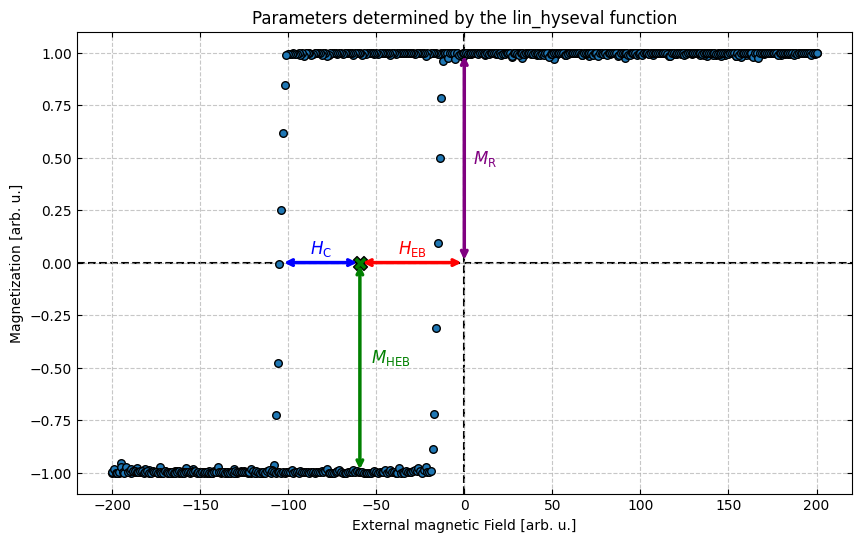

In [73]:
from pathlib import Path
import pandas as pd
from evaluix.utils import HysteresisFunctions as hf

csv_path = Path.cwd().parent / "_static" / "simulated" / "simulated_hysteresis_loop.csv"
data = pd.read_csv(csv_path)

print(data.head())

fields = data.iloc[:, 0].values
magnetization = data.iloc[:, 1].values
lin_params = hf.lin_hyseval(fields, magnetization)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(fields, magnetization, label='Original Data', edgecolor='k', s=30, zorder=5)
ax.scatter(lin_params['HEB'], 0, color='g', label='HEB', zorder=10, s=100, edgecolor='k', marker='X')
ax.set_title('Parameters determined by the lin_hyseval function')
ax.set_xlabel('External magnetic Field [arb. u.]')
ax.set_ylabel('Magnetization [arb. u.]')
ax.tick_params(direction='in', top=True, right=True)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.axvline(0, color='k', linestyle='--', zorder=1)
ax.axhline(0, color='k', linestyle='--', zorder=1)

# HEB arrow from 0 to HEB with text above the arrow
heb_y = 0
ax.annotate(
    '',
    xy=(lin_params['HEB'], 0),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='<->', facecolor='red', edgecolor='red', lw=2.5),
    zorder=10,
 )
ax.text(
    0.5 * lin_params['HEB'],
    0.02,
    r'$H_\mathrm{EB}$',
    color='red',
    fontsize=12,
    ha='center',
    va='bottom',
    zorder=11,
 )

# HC arrow from HEB to HEB - HC with text above the arrow
ax.annotate(
    '',
    xy=(lin_params['HEB'] - lin_params['HC'], 0),
    xytext=(lin_params['HEB'], 0),
    arrowprops=dict(arrowstyle='<->', facecolor='blue', edgecolor='blue', lw=2.5),
    zorder=10,
 )
ax.text(
    lin_params['HEB'] - 0.5 * lin_params['HC'],
    0.02,
    r'$H_\mathrm{C}$',
    color='blue',
    fontsize=12,
    ha='center',
    va='bottom',
    zorder=11,
 )

# MHEB from 0 to -MHEB at x=HEB with text to the right of the arrow
ax.annotate(
    '',
    xy=(lin_params['HEB'], 0),
    xytext=(lin_params['HEB'], -lin_params['MHEB'][0]),
    arrowprops=dict(arrowstyle='<->', facecolor='green', edgecolor='green', lw=2.5),
    zorder=10,
    )
ax.text(
    0.7 * lin_params['HEB'],
    - 0.5 *lin_params['MHEB'][0],
    r'$M_\mathrm{HEB}$',
    color='green',
    fontsize=12,
    ha='center',
    va='bottom',
    zorder=11,
    )

# MR from 0,0 to 0,MR with text to the right of the arrow
ax.annotate(
    '',
    xy=(0, lin_params['MR'][0]),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='<->', facecolor='purple', edgecolor='purple', lw=2.5),
    zorder=10,
 )
ax.text(
    5, 0.5 * lin_params['MR'][0],
    r'$M_\mathrm{R}$',
    color='purple',
    fontsize=12,
    ha='left',
    va='center',
    zorder=11,
 )

## arctan_hyseval


In [16]:

arctan_fit, arctan_params, arctan_results = hf.arctan_hyseval(fields, magnetization)

for key, value in lin_params.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

HEB: -59.2806
dHEB: 1.2799
HC: 44.6951
dHC: 1.2799
MR: (np.float64(0.9975272000594728), np.float64(0.995171333792492), np.float64(0.9998830663264536))
dMR: 0.0024
MHEB: (np.float64(0.998062793558943), np.float64(0.9977309555056842), np.float64(-0.9983946316122018))
dMHEB: 0.0012
